In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [49]:
# Check GPU availability - crucial for training speed
!nvidia-smi

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Sun Sep  6 18:58:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             32W /   70W |    1343MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [50]:
!pip install -q kaggle torchmetrics grad-cam
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
from sklearn.model_selection import train_test_split
import json

In [51]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

print("Seed function defined")

Seed function defined


In [52]:
BASE_DIR = Path('/content/drive/MyDrive/pneumonia_project')
dirs = ['data/raw', 'data/processed', 'models', 'notebooks', 'results/figures', 'results/logs']
for d in dirs: (BASE_DIR / d).mkdir(parents=True, exist_ok=True)
print("Created:", BASE_DIR)

Created: /content/drive/MyDrive/pneumonia_project


In [53]:
!pip install -q kagglehub
import kagglehub

In [54]:
dataset_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Downloaded to:", dataset_path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Downloaded to: /kaggle/input/chest-xray-pneumonia


In [55]:
data_root = Path("/content/drive/MyDrive/pneumonia_project/data/raw/chest_xray/chest_xray")
print("Updated data_root:", data_root)

Updated data_root: /content/drive/MyDrive/pneumonia_project/data/raw/chest_xray/chest_xray


In [56]:
for split in ['train', 'test', 'val']:
    split_path = data_root / split
    if split_path.exists():
        normal_count = len(list((split_path / 'NORMAL').glob('*.jpeg')))
        pneumonia_count = len(list((split_path / 'PNEUMONIA').glob('*.jpeg')))
        total = normal_count + pneumonia_count
        print(f"{split.upper():6s} | NORMAL: {normal_count:4d} | PNEUMONIA: {pneumonia_count:4d} | Total: {total:4d} | Imbalance ratio: {pneumonia_count/normal_count:.2f}:1")

TRAIN  | NORMAL: 1341 | PNEUMONIA: 3875 | Total: 5216 | Imbalance ratio: 2.89:1
TEST   | NORMAL:  234 | PNEUMONIA:  390 | Total:  624 | Imbalance ratio: 1.67:1
VAL    | NORMAL:    8 | PNEUMONIA:    8 | Total:   16 | Imbalance ratio: 1.00:1


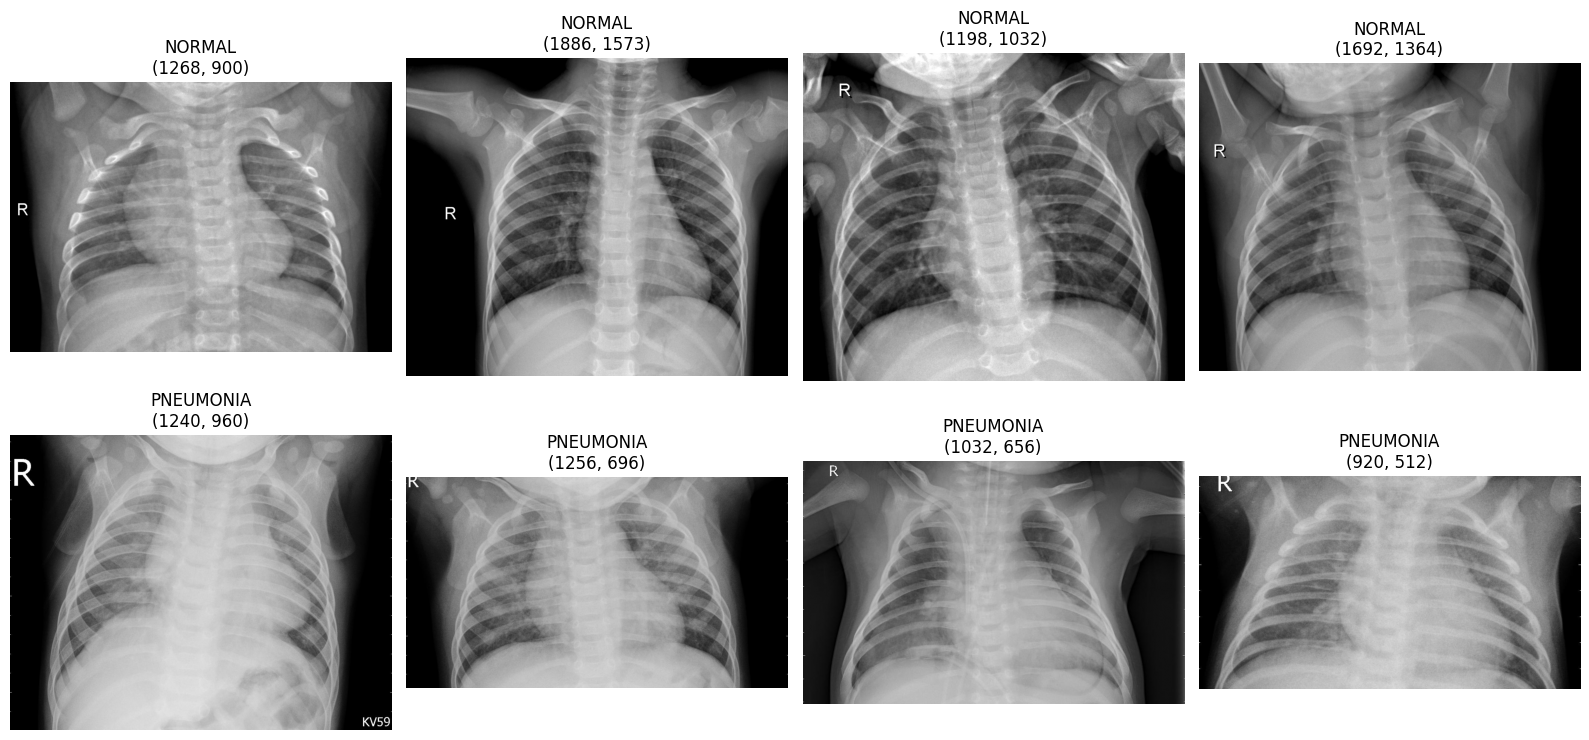

In [9]:
import random
from PIL import Image

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, cls in enumerate(['NORMAL', 'PNEUMONIA']):
    sample_files = random.sample(list((data_root / 'train' / cls).glob('*.jpeg')), 4)
    for j, f in enumerate(sample_files):
        img = Image.open(f)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].set_title(f"{cls}\n{img.size}")
        axes[i, j].axis('off')
plt.tight_layout()
plt.show()

In [57]:
expected = {
    ('train', 'NORMAL'): 1341, ('train', 'PNEUMONIA'): 3875,
    ('test', 'NORMAL'): 234, ('test', 'PNEUMONIA'): 390,
    ('val', 'NORMAL'): 8, ('val', 'PNEUMONIA'): 8,
}

all_good = True
for (split, cls), expected_count in expected.items():
    p = data_root / split / cls
    actual = len(os.listdir(p)) if p.exists() else 0
    status = "✓" if actual == expected_count else "✗ MISMATCH"
    if actual != expected_count:
        all_good = False
    print(f"{split}/{cls}: {actual} (expected {expected_count}) {status}")

print("\nAll folders complete!" if all_good else "\nSome folders still need fixing.")

train/NORMAL: 1341 (expected 1341) ✓
train/PNEUMONIA: 3875 (expected 3875) ✓
test/NORMAL: 234 (expected 234) ✓
test/PNEUMONIA: 390 (expected 390) ✓
val/NORMAL: 8 (expected 8) ✓
val/PNEUMONIA: 8 (expected 8) ✓

All folders complete!


In [58]:
from torchvision import transforms

# Transform for training images - includes light augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Transform for validation/test images - NO augmentation, just resize + normalize
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("Transforms defined")

Transforms defined


In [59]:
from torch.utils.data import Dataset
from PIL import Image

class ChestXrayDataset(Dataset):
    def __init__(self, image_paths, labels, transform):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        label = self.labels[idx]
        return image, label

print("Dataset class defined")

Dataset class defined


In [60]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [62]:
import shutil
import time

local_root = Path('/content/chest_xray_local')

def copy_with_progress(source, dest):
    dest.mkdir(parents=True, exist_ok=True)
    files = list(source.glob('*.jpeg'))
    for f in files:
        shutil.copy2(f, dest / f.name)
    return len(files)

start = time.time()
for split in ['train', 'test', 'val']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        source = data_root / split / cls
        dest = local_root / split / cls
        count = copy_with_progress(source, dest)
        print(f"{split}/{cls}: copied {count} files")

print(f"\nTotal time: {time.time() - start:.1f} seconds")

train/NORMAL: copied 1341 files
train/PNEUMONIA: copied 3875 files
test/NORMAL: copied 234 files
test/PNEUMONIA: copied 390 files
val/NORMAL: copied 8 files
val/PNEUMONIA: copied 8 files

Total time: 41.1 seconds


In [17]:
data_root_local = local_root  # /content/chest_xray_local

train_dir = data_root_local / 'train'
image_paths = []
labels = []
for cls, label in [('NORMAL', 0), ('PNEUMONIA', 1)]:
    for img_path in (train_dir / cls).glob('*.jpeg'):
        image_paths.append(img_path)
        labels.append(label)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.15, stratify=labels, random_state=42
)

train_dataset = ChestXrayDataset(train_paths, train_labels, train_transform)
val_dataset = ChestXrayDataset(val_paths, val_labels, val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")
print("DataLoaders now pointing at local disk")

Train: 4433, Val: 783
DataLoaders now pointing at local disk


In [18]:
test_dir = local_root / 'test'
test_paths = []
test_labels = []
for cls, label in [('NORMAL', 0), ('PNEUMONIA', 1)]:
    for img_path in (test_dir / cls).glob('*.jpeg'):
        test_paths.append(img_path)
        test_labels.append(label)

test_dataset = ChestXrayDataset(test_paths, test_labels, val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print(f"Test images: {len(test_dataset)}")

Test images: 624


In [63]:
import torch.optim as optim

# Calculate class weights - inversely proportional to how common each class is
normal_count = train_labels.count(0)
pneumonia_count = train_labels.count(1)
total = normal_count + pneumonia_count

weight_normal = total / (2 * normal_count)
weight_pneumonia = total / (2 * pneumonia_count)

class_weights = torch.tensor([weight_normal, weight_pneumonia]).to(device)
print(f"Class weights - NORMAL: {weight_normal:.3f}, PNEUMONIA: {weight_pneumonia:.3f}")



Class weights - NORMAL: 1.944, PNEUMONIA: 0.673


In [64]:
## Experiment no. 1 with no regularization
model = models.resnet18(weights='IMAGENET1K_V1')
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)
print("Model rebuilt (baseline - no dropout)")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
print("Baseline loss/optimizer ready (no weight decay)")

Model rebuilt (baseline - no dropout)
Baseline loss/optimizer ready (no weight decay)


In [65]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()  # tells the model "you're being tested, not learning"
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # don't waste effort calculating adjustments we won't use
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

print("Validation function defined")

Validation function defined


In [66]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        # NEW: print progress every 20 batches
        if (batch_idx + 1) % 20 == 0:
            print(f"  Batch {batch_idx+1}/{len(loader)} - running loss: {running_loss/total:.4f}")

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

print("Training function updated with progress printing")

Training function updated with progress printing


In [67]:
import json

NUM_EPOCHS = 10

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model_save_path = BASE_DIR / 'models' / 'best_model.pth'
        torch.save(model.state_dict(), model_save_path)
        print(f"  → New best model saved (val acc: {val_acc:.4f})")

# NEW: save history to a file in Drive, so it's never lost again
history_path = BASE_DIR / 'results/logs/history.json'
with open(history_path, 'w') as f:
    json.dump(history, f)

print("\nTraining complete!")
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"History saved to: {history_path}")

  Batch 20/139 - running loss: 0.2402
  Batch 40/139 - running loss: 0.1857
  Batch 60/139 - running loss: 0.1705
  Batch 80/139 - running loss: 0.1531
  Batch 100/139 - running loss: 0.1417
  Batch 120/139 - running loss: 0.1376
Epoch 1/10 | Train Loss: 0.1352, Train Acc: 0.9461 | Val Loss: 0.0674, Val Acc: 0.9860
  → New best model saved (val acc: 0.9860)
  Batch 20/139 - running loss: 0.0556
  Batch 40/139 - running loss: 0.0657
  Batch 60/139 - running loss: 0.0621
  Batch 80/139 - running loss: 0.0703
  Batch 100/139 - running loss: 0.0740
  Batch 120/139 - running loss: 0.0670
Epoch 2/10 | Train Loss: 0.0667, Train Acc: 0.9745 | Val Loss: 0.0852, Val Acc: 0.9617
  Batch 20/139 - running loss: 0.0772
  Batch 40/139 - running loss: 0.0642
  Batch 60/139 - running loss: 0.0577
  Batch 80/139 - running loss: 0.0540
  Batch 100/139 - running loss: 0.0537
  Batch 120/139 - running loss: 0.0480
Epoch 3/10 | Train Loss: 0.0454, Train Acc: 0.9811 | Val Loss: 0.0376, Val Acc: 0.9821
  Batc

Saved to: /content/drive/MyDrive/pneumonia_project/results/figures/training_curves.png


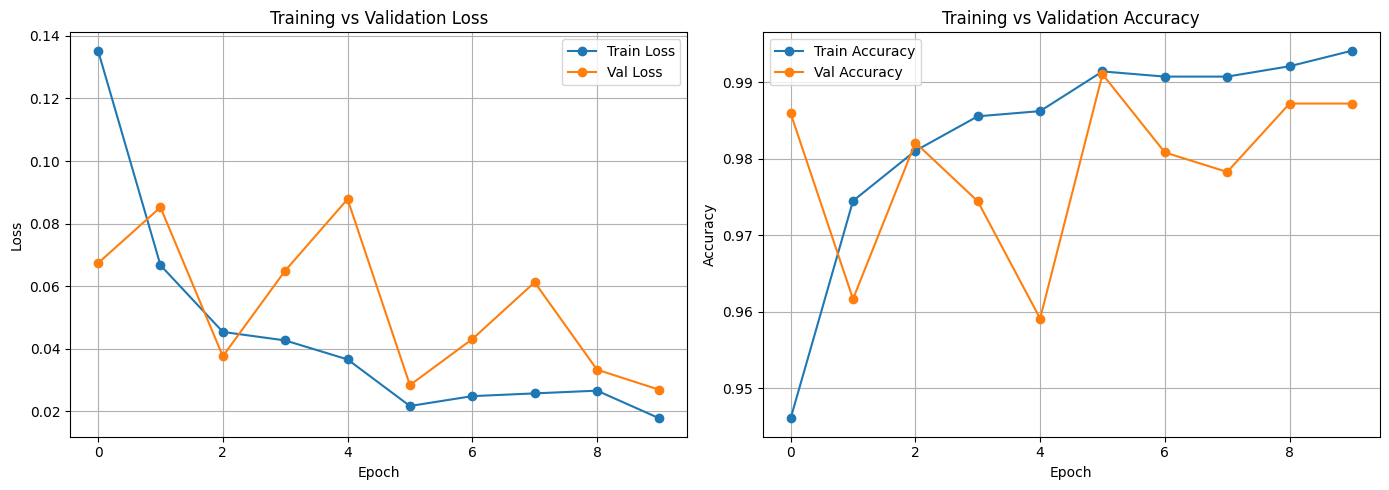

In [68]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy curve
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

# Save it too
save_path = BASE_DIR / 'results/figures/training_curves.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved to: {save_path}")

plt.show()

In [69]:
model.load_state_dict(torch.load(BASE_DIR / 'models/best_model.pth'))
model.eval()
print("Best model loaded — ready for evaluation")

Best model loaded — ready for evaluation


In [70]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

test_accuracy = sum([p == l for p, l in zip(all_preds, all_labels)]) / len(all_labels)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.8413


In [71]:
import json

test_results = {
    'predictions': [int(p) for p in all_preds],
    'true_labels': [int(l) for l in all_labels],
    'test_accuracy': float(test_accuracy)
}

results_path = BASE_DIR / 'results/logs/test_results_baseline.json'
with open(results_path, 'w') as f:
    json.dump(test_results, f)

print(f"Test results saved to: {results_path}")

Test results saved to: /content/drive/MyDrive/pneumonia_project/results/logs/test_results_baseline.json


Confusion Matrix:
[[136  98]
 [  1 389]]

Detailed report:
              precision    recall  f1-score   support

      NORMAL       0.99      0.58      0.73       234
   PNEUMONIA       0.80      1.00      0.89       390

    accuracy                           0.84       624
   macro avg       0.90      0.79      0.81       624
weighted avg       0.87      0.84      0.83       624



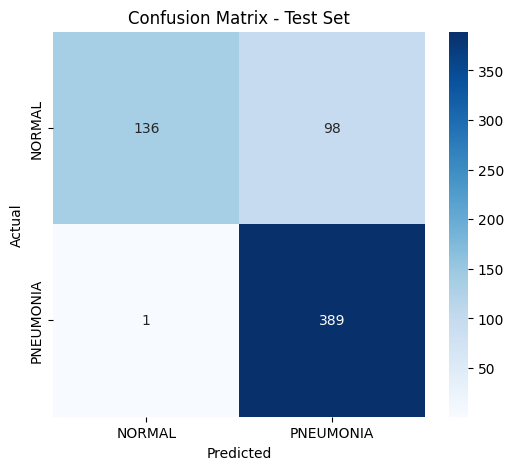

In [72]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

print("\nDetailed report:")
print(classification_report(all_labels, all_preds, target_names=['NORMAL', 'PNEUMONIA']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.savefig(BASE_DIR / 'results/figures/confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

In [73]:
import torchvision.models as models
import torch.nn as nn
## Experiment 2: Fine-tuned with Dropout + Weight Decay

model = models.resnet18(weights='IMAGENET1K_V1')
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 2)
)
model = model.to(device)
print("Model rebuilt with dropout")

# Optimizer with weight decay added
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
print("Optimizer updated with weight decay")

Model rebuilt with dropout
Optimizer updated with weight decay


In [74]:
import json

NUM_EPOCHS = 15
PATIENCE = 2

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
epochs_without_improvement = 0
history_path = BASE_DIR / 'results/logs/history_regularized.json'

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Save history after EVERY epoch now, not just at the end
    with open(history_path, 'w') as f:
        json.dump(history, f)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), BASE_DIR / 'models/best_model_regularized.pth')
        print(f"  → New best model saved (val acc: {val_acc:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"  → No improvement for {epochs_without_improvement} epoch(s)")

    if epochs_without_improvement >= PATIENCE:
        print(f"\nStopping early — no improvement for {PATIENCE} epochs in a row")
        break

print(f"\nTraining complete! Best validation accuracy: {best_val_acc:.4f}")
print(f"History saved to: {history_path}")

  Batch 20/139 - running loss: 0.3219
  Batch 40/139 - running loss: 0.2266
  Batch 60/139 - running loss: 0.1968
  Batch 80/139 - running loss: 0.1778
  Batch 100/139 - running loss: 0.1689
  Batch 120/139 - running loss: 0.1597
Epoch 1/15 | Train Loss: 0.1511, Train Acc: 0.9377 | Val Loss: 0.1337, Val Acc: 0.9425
  → New best model saved (val acc: 0.9425)
  Batch 20/139 - running loss: 0.0635
  Batch 40/139 - running loss: 0.0783
  Batch 60/139 - running loss: 0.0797
  Batch 80/139 - running loss: 0.0803
  Batch 100/139 - running loss: 0.0762
  Batch 120/139 - running loss: 0.0745
Epoch 2/15 | Train Loss: 0.0724, Train Acc: 0.9729 | Val Loss: 0.1107, Val Acc: 0.9476
  → New best model saved (val acc: 0.9476)
  Batch 20/139 - running loss: 0.0486
  Batch 40/139 - running loss: 0.0500
  Batch 60/139 - running loss: 0.0548
  Batch 80/139 - running loss: 0.0536
  Batch 100/139 - running loss: 0.0628
  Batch 120/139 - running loss: 0.0621
Epoch 3/15 | Train Loss: 0.0587, Train Acc: 0.9788

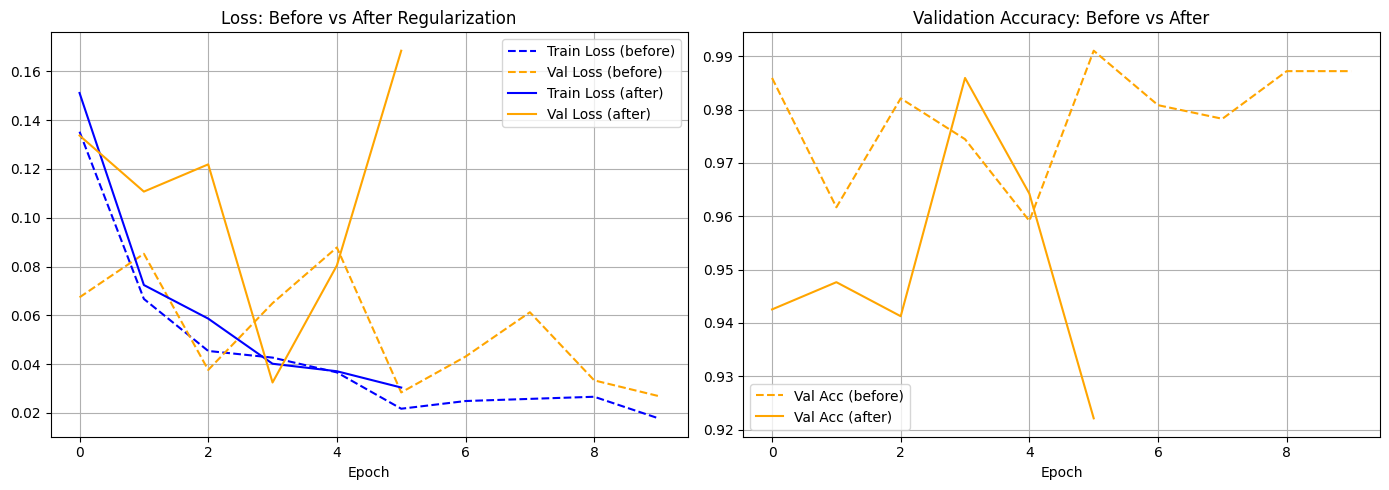

In [75]:
with open(BASE_DIR / 'results/logs/history.json') as f:
    history_before = json.load(f)

with open(BASE_DIR / 'results/logs/history_regularized.json') as f:
    history_after = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_before['train_loss'], label='Train Loss (before)', linestyle='--', color='blue')
axes[0].plot(history_before['val_loss'], label='Val Loss (before)', linestyle='--', color='orange')
axes[0].plot(history_after['train_loss'], label='Train Loss (after)', color='blue')
axes[0].plot(history_after['val_loss'], label='Val Loss (after)', color='orange')
axes[0].set_title('Loss: Before vs After Regularization')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_before['val_acc'], label='Val Acc (before)', linestyle='--', color='orange')
axes[1].plot(history_after['val_acc'], label='Val Acc (after)', color='orange')
axes[1].set_title('Validation Accuracy: Before vs After')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(BASE_DIR / 'results/figures/overfitting_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [76]:
model = models.resnet18(weights='IMAGENET1K_V1')
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 2)
)
model = model.to(device)

model.load_state_dict(torch.load(BASE_DIR / 'models/best_model_regularized.pth'))
model.eval()
print("Regularized model loaded — ready for evaluation")

Regularized model loaded — ready for evaluation


In [77]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

test_accuracy = sum([p == l for p, l in zip(all_preds, all_labels)]) / len(all_labels)
print(f"Test Accuracy (regularized): {test_accuracy:.4f}")

Test Accuracy (regularized): 0.8670


In [78]:
test_results = {
    'predictions': [int(p) for p in all_preds],
    'true_labels': [int(l) for l in all_labels],
    'test_accuracy': float(test_accuracy)
}
with open(BASE_DIR / 'results/logs/test_results_regularized.json', 'w') as f:
    json.dump(test_results, f)
print("Saved")

Saved


Confusion Matrix (regularized):
[[153  81]
 [  2 388]]

Detailed report:
              precision    recall  f1-score   support

      NORMAL       0.99      0.65      0.79       234
   PNEUMONIA       0.83      0.99      0.90       390

    accuracy                           0.87       624
   macro avg       0.91      0.82      0.85       624
weighted avg       0.89      0.87      0.86       624



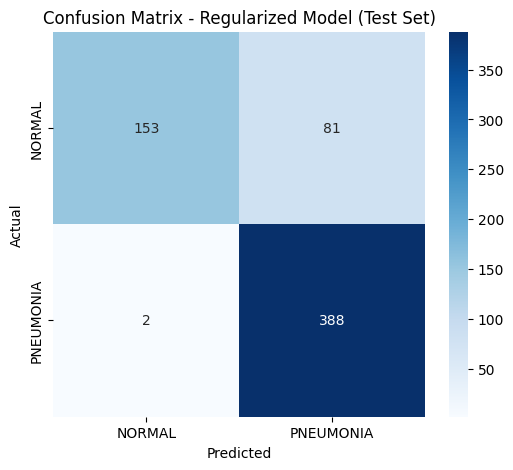

In [79]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix (regularized):")
print(cm)
print("\nDetailed report:")
print(classification_report(all_labels, all_preds, target_names=['NORMAL', 'PNEUMONIA']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Regularized Model (Test Set)')
plt.savefig(BASE_DIR / 'results/figures/confusion_matrix_regularized.png', dpi=150, bbox_inches='tight')
plt.show()

In [80]:
import json

with open(BASE_DIR / 'results/logs/test_results.json') as f:
    results_exp1 = json.load(f)

with open(BASE_DIR / 'results/logs/test_results_regularized.json') as f:
    results_exp2 = json.load(f)

preds_match = results_exp1['predictions'] == results_exp2['predictions']
print(f"Are Experiment 1 and Experiment 2 predictions EXACTLY identical? {preds_match}")

if preds_match:
    print("This confirms both experiments produced literally the same predictions")
else:
    # Count how many actually differ
    diffs = sum(1 for a, b in zip(results_exp1['predictions'], results_exp2['predictions']) if a != b)
    print(f"They differ on {diffs} out of {len(results_exp1['predictions'])} images")

Are Experiment 1 and Experiment 2 predictions EXACTLY identical? False
They differ on 129 out of 624 images


In [81]:
## Experiment 3: Frozen Backbone (no class weights)
model = models.resnet18(weights='IMAGENET1K_V1')
for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable} out of {total_params} total")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
print("Ready to train")

Trainable parameters: 1026 out of 11177538 total
Ready to train


In [82]:
NUM_EPOCHS = 15
PATIENCE = 2

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
epochs_without_improvement = 0
history_path = BASE_DIR / 'results/logs/history_frozen.json'

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    with open(history_path, 'w') as f:
        json.dump(history, f)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), BASE_DIR / 'models/best_model_frozen.pth')
        print(f"  → New best model saved (val acc: {val_acc:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"  → No improvement for {epochs_without_improvement} epoch(s)")

    if epochs_without_improvement >= PATIENCE:
        print(f"\nStopping early — no improvement for {PATIENCE} epochs in a row")
        break

print(f"\nTraining complete! Best validation accuracy: {best_val_acc:.4f}")

  Batch 20/139 - running loss: 0.5132
  Batch 40/139 - running loss: 0.4464
  Batch 60/139 - running loss: 0.3939
  Batch 80/139 - running loss: 0.3629
  Batch 100/139 - running loss: 0.3414
  Batch 120/139 - running loss: 0.3255
Epoch 1/15 | Train Loss: 0.3129, Train Acc: 0.8683 | Val Loss: 0.2547, Val Acc: 0.9029
  → New best model saved (val acc: 0.9029)
  Batch 20/139 - running loss: 0.2126
  Batch 40/139 - running loss: 0.2024
  Batch 60/139 - running loss: 0.2007
  Batch 80/139 - running loss: 0.2056
  Batch 100/139 - running loss: 0.2083
  Batch 120/139 - running loss: 0.2054
Epoch 2/15 | Train Loss: 0.2053, Train Acc: 0.9224 | Val Loss: 0.2149, Val Acc: 0.9208
  → New best model saved (val acc: 0.9208)
  Batch 20/139 - running loss: 0.1780
  Batch 40/139 - running loss: 0.1789
  Batch 60/139 - running loss: 0.1847
  Batch 80/139 - running loss: 0.1908
  Batch 100/139 - running loss: 0.1863
  Batch 120/139 - running loss: 0.1838
Epoch 3/15 | Train Loss: 0.1768, Train Acc: 0.9303

In [83]:
# Rebuild the exact same frozen architecture, then load its trained weights
model = models.resnet18(weights='IMAGENET1K_V1')
for param in model.parameters():
    param.requires_grad = False
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

model.load_state_dict(torch.load(BASE_DIR / 'models/best_model_frozen.pth'))
model.eval()
print("Frozen model loaded")

# Build test set from local copy
test_dir = local_root / 'test'
test_paths = []
test_labels = []
for cls, label in [('NORMAL', 0), ('PNEUMONIA', 1)]:
    for img_path in (test_dir / cls).glob('*.jpeg'):
        test_paths.append(img_path)
        test_labels.append(label)

test_dataset = ChestXrayDataset(test_paths, test_labels, val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print(f"Test images: {len(test_dataset)}")

Frozen model loaded
Test images: 624


In [84]:
all_preds_frozen = []
all_labels_frozen = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds_frozen.extend(predicted.cpu().numpy())
        all_labels_frozen.extend(labels.numpy())

test_accuracy_frozen = sum([p == l for p, l in zip(all_preds_frozen, all_labels_frozen)]) / len(all_labels_frozen)
print(f"Test Accuracy (frozen backbone): {test_accuracy_frozen:.4f}")

# Save immediately, separate filename
test_results_frozen = {
    'predictions': [int(p) for p in all_preds_frozen],
    'true_labels': [int(l) for l in all_labels_frozen],
    'test_accuracy': float(test_accuracy_frozen)
}
with open(BASE_DIR / 'results/logs/test_results_frozen.json', 'w') as f:
    json.dump(test_results_frozen, f)
print("Saved")

Test Accuracy (frozen backbone): 0.8766
Saved


In [86]:


cm_frozen = confusion_matrix(all_labels_frozen, all_preds_frozen)
print("Confusion Matrix (frozen backbone):")
print(cm_frozen)

print("\nDetailed report:")
print(classification_report(all_labels_frozen, all_preds_frozen, target_names=['NORMAL', 'PNEUMONIA']))

Confusion Matrix (frozen backbone):
[[163  71]
 [  6 384]]

Detailed report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.70      0.81       234
   PNEUMONIA       0.84      0.98      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.84      0.86       624
weighted avg       0.89      0.88      0.87       624



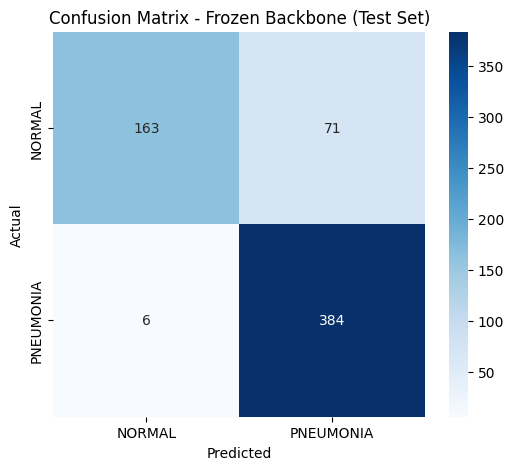

In [87]:
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm_frozen, annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Frozen Backbone (Test Set)')
plt.savefig(BASE_DIR / 'results/figures/confusion_matrix_frozen.png', dpi=150, bbox_inches='tight')
plt.show()

In [88]:
## Experiment 4: Partial Unfreeze (layer4) + Differential Learning Rates

# Start fresh, from pretrained ImageNet weights - don't rely on leftover state from Experiment 3
model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Selectively unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace final layer with dropout
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 2)
)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable} out of {total_params} total")

# Differential learning rates
optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 0.00001},
    {'params': model.fc.parameters(), 'lr': 0.001}
], weight_decay=1e-4)

criterion = nn.CrossEntropyLoss()
print("Optimizer and loss ready (differential LR, unweighted loss)")

Trainable parameters: 8394754 out of 11177538 total
Optimizer and loss ready (differential LR, unweighted loss)


In [89]:
NUM_EPOCHS = 15
PATIENCE = 2

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
epochs_without_improvement = 0
history_path = BASE_DIR / 'results/logs/history_partial_unfreeze.json'

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    with open(history_path, 'w') as f:
        json.dump(history, f)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), BASE_DIR / 'models/best_model_partial_unfreeze.pth')
        print(f"  → New best model saved (val acc: {val_acc:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"  → No improvement for {epochs_without_improvement} epoch(s)")

    if epochs_without_improvement >= PATIENCE:
        print(f"\nStopping early — no improvement for {PATIENCE} epochs in a row")
        break

print(f"\nTraining complete! Best validation accuracy: {best_val_acc:.4f}")

  Batch 20/139 - running loss: 0.4860
  Batch 40/139 - running loss: 0.3803
  Batch 60/139 - running loss: 0.3414
  Batch 80/139 - running loss: 0.3113
  Batch 100/139 - running loss: 0.2936
  Batch 120/139 - running loss: 0.2743
Epoch 1/15 | Train Loss: 0.2592, Train Acc: 0.8897 | Val Loss: 0.1334, Val Acc: 0.9502
  → New best model saved (val acc: 0.9502)
  Batch 20/139 - running loss: 0.1598
  Batch 40/139 - running loss: 0.1605
  Batch 60/139 - running loss: 0.1512
  Batch 80/139 - running loss: 0.1467
  Batch 100/139 - running loss: 0.1399
  Batch 120/139 - running loss: 0.1358
Epoch 2/15 | Train Loss: 0.1402, Train Acc: 0.9452 | Val Loss: 0.1253, Val Acc: 0.9527
  → New best model saved (val acc: 0.9527)
  Batch 20/139 - running loss: 0.1094
  Batch 40/139 - running loss: 0.1161
  Batch 60/139 - running loss: 0.1094
  Batch 80/139 - running loss: 0.1129
  Batch 100/139 - running loss: 0.1203
  Batch 120/139 - running loss: 0.1199
Epoch 3/15 | Train Loss: 0.1169, Train Acc: 0.9562

In [90]:
# Rebuild the exact same partial-unfreeze architecture, then load its trained weights
model = models.resnet18(weights='IMAGENET1K_V1')
for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 2)
)
model = model.to(device)

model.load_state_dict(torch.load(BASE_DIR / 'models/best_model_partial_unfreeze.pth'))
model.eval()
print("Partial-unfreeze model loaded")

all_preds_pu = []
all_labels_pu = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds_pu.extend(predicted.cpu().numpy())
        all_labels_pu.extend(labels.numpy())

test_accuracy_pu = sum([p == l for p, l in zip(all_preds_pu, all_labels_pu)]) / len(all_labels_pu)
print(f"Test Accuracy (partial unfreeze): {test_accuracy_pu:.4f}")

test_results_pu = {
    'predictions': [int(p) for p in all_preds_pu],
    'true_labels': [int(l) for l in all_labels_pu],
    'test_accuracy': float(test_accuracy_pu)
}
with open(BASE_DIR / 'results/logs/test_results_partial_unfreeze.json', 'w') as f:
    json.dump(test_results_pu, f)
print("Saved")
from sklearn.metrics import confusion_matrix, classification_report
cm_pu = confusion_matrix(all_labels_pu, all_preds_pu)
print("\nConfusion Matrix:")
print(cm_pu)
print("\nDetailed report:")
print(classification_report(all_labels_pu, all_preds_pu, target_names=['NORMAL', 'PNEUMONIA']))

Partial-unfreeze model loaded
Test Accuracy (partial unfreeze): 0.8670
Saved

Confusion Matrix:
[[154  80]
 [  3 387]]

Detailed report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.66      0.79       234
   PNEUMONIA       0.83      0.99      0.90       390

    accuracy                           0.87       624
   macro avg       0.90      0.83      0.85       624
weighted avg       0.89      0.87      0.86       624



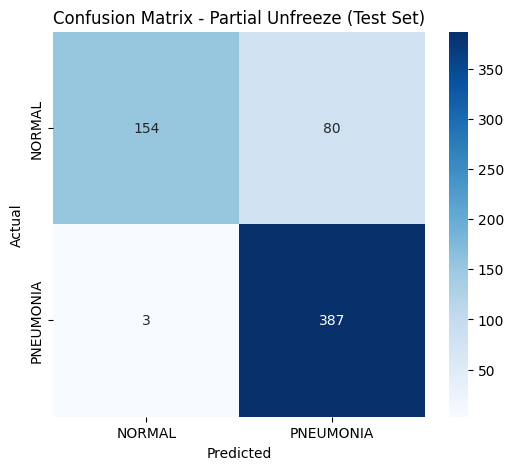

In [91]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_pu, annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Partial Unfreeze (Test Set)')
plt.savefig(BASE_DIR / 'results/figures/confusion_matrix_partial_unfreeze.png', dpi=150, bbox_inches='tight')
plt.show()